# Домашня робота 4 — Neural Architecture Search з Hyperopt (CNN / CIFAR-10)

**Курс:** Efficient ML, SET University

Neural Architecture Search (NAS) — це автоматичний пошук самої **архітектури** мережі,
а не її ваг. Замість того щоб вручну вгадувати «скільки шарів, які блоки, яка ширина»,
ми задаємо **дискретний простір** можливих архітектур і даємо оптимізатору знайти в
ньому найкращу. Тут оптимізатор — **TPE** (Tree-structured Parzen Estimator) з
[Hyperopt](https://github.com/hyperopt/hyperopt).

Головна проблема NAS — вартість: повноцінно натренувати кожну архітектуру з нуля надто
дорого. Рятує **weight sharing (one-shot)**: ми один раз тренуємо велику
**supernet**, чиї ваги спільні для всього простору, і оцінюємо будь-яку архітектуру
як її під-мережу — **без окремого навчання**. Це рівно та ідея slimmable-мереж, яку
ми вже застосували в бонусі ДЗ3 (NetAug), тільки тепер розширена на **вибір операції**
в кожній стадії.

### Що ми шукали (три осі, як вимагає умова)

| Вісь | Варіанти |
|---|---|
| **Операція блоку** (на кожну з 4 стадій) | `conv3x3` (звичайна згортка) · `dwsep` (depthwise-separable, MobileNet-v1) · `mbconv` (inverted residual, MobileNet-v2, expand ×3) |
| **Множник ширини** (глобальний) | 0.5 · 0.75 · 1.0 · 1.25 |
| **Активація** (глобальна) | ReLU · ReLU6 · SiLU · GELU · LeakyReLU |

Розмір простору = 3⁴ × 4 × 5 = **1620 архітектур**.

### Головний результат (тест — раз на кожну фінальну модель; 3 seed-и, mean ± std)

| Модель | Параметри | Test acc |
|---|---|---|
| Baseline VGG11 (з ДЗ1, reference — один запуск) | 9.49M | 90.71% |
| In-space default (усі conv3x3, 1.0×, ReLU) | 0.96M | 90.16 ± 0.17% |
| **Знайдена пошуком** (conv3x3/mbconv/mbconv/conv3x3, 1.0×, relu) | **0.79M** | **91.02 ± 0.16%** |

**Основний висновок — знайдена архітектура vs in-space default** (обидві на 3
seed-ах, ідентичний рецепт, однаковий порядок батчів на кожному seed): **+0.86 п.п.**
(91.02 ± 0.16% проти 90.16 ± 0.17%) при трохи
меншій кількості параметрів. Розрив перевищує сумарний розкид (±0.16/
±0.17 п.п.), тож пошук **реально** дав кращу архітектуру, а не удачу seed.

Проти **VGG11** знайдена мережа — +0.31 п.п. при **12.1×
менше параметрів**. Але VGG11-baseline має лише **один історичний запуск**, тож це радше
порівняння з reference-точкою, ніж статистично доведена перевага; головне тут — що пошук
дотягується до рівня набагато більшої мережі на порядок меншою.

Наскільки надійним був one-shot proxy? На вибірці, що покриває **весь** діапазон proxy
(стратифіковано по квантилях): Kendall τ = **0.57**
(p<0.001) — тобто для **грубого** відсіву proxy надійний. А на **топ**
кандидатах: τ = **-0.07** (p=1.000) — **тонко**
ранжувати найкращих між собою він майже не вміє. Деталі — у розділах 4–6 і висновках.

## 1. Підготовка

Цей ноутбук — **звіт-візуалізація**: він завантажує готові метрики з `results/*.json`,
а самі експерименти (тренування supernet, пошук, retrain) виконують скрипти на GPU.
Точні команди відтворення:

```bash
# тренує supernet з нуля (~8 хв на GB10) і шукає; supernet.pt зберігається в results/
python run_search.py     --supernet-epochs 100 --evals 250
python run_retrain.py    --baseline ../hw1/results/baseline.pt --epochs 120 --seeds 42,43,44
python run_proxy_corr.py --n-bins 4 --per-bin 4 --top-k 6 --seeds 42,43 --short-epochs 15
python tests/test_search_space.py && python tests/test_supernet.py
```
> `run_search.py` має також опцію `--load-supernet results/supernet.pt` для перевикористання
> ваг, але сам чекпойнт `*.pt` не комітиться (gitignored), тож для відтворення з нуля —
> команда вище (тренує supernet заново; результат детермінований за seed з точністю до
> GPU-недетермінізму).

Прогін цього ДЗ — на gx10 (NVIDIA GB10, CUDA 13.0), single-seed для пошуку/supernet,
3 seed-и для retrain. Версії середовища друкуються нижче.

In [1]:
import json, sys, platform
import torch, torchvision, numpy, scipy, hyperopt
import matplotlib.pyplot as plt

from src.utils import get_device
from src.search_space import space_size, count_arch_params, StandaloneNet, sample_arch
from src import plots

print("python     ", sys.version.split()[0], "|", platform.platform())
print("torch      ", torch.__version__, "| torchvision", torchvision.__version__)
print("numpy      ", numpy.__version__, "| scipy", scipy.__version__,
      "| hyperopt", hyperopt.__version__)
print("device     ", get_device(),
      "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

RESULTS = "results"
def load(n):
    with open(f"{RESULTS}/{n}") as f: return json.load(f)
search   = load("search.json")
retrain  = load("retrain.json")
corr     = load("proxy_corr.json")
records  = search["records"]
print("простір    ", space_size(), "архітектур")

python      3.12.3 | Linux-6.17.0-1018-nvidia-aarch64-with-glibc2.39
torch       2.11.0+cu130 | torchvision 0.26.0+cu130
numpy       2.4.4 | scipy 1.17.1 | hyperopt 0.2.7
device      cuda | NVIDIA GB10
простір     1620 архітектур


## 2. Простір пошуку

Макро-скелет **фіксований**: 4 послідовні стадії, кожна = один шуканий блок + 2×2
max-pool (32→16→8→4→2 по просторовому розміру), потім global average pooling і
лінійний класифікатор. Пошук вирішує лише **що` за блок** у кожній стадії, **яку
ширину** й **яку активацію** — рівно три осі з умови.

Три операції — це класична «сходинка ефективності»:
- **`conv3x3`** — повна згортка 3×3: найвиразніша, найважча за параметрами;
- **`dwsep`** — depthwise 3×3 + pointwise 1×1: та сама форма, у рази менше параметрів;
- **`mbconv`** — inverted residual (expand→depthwise→project, +skip): компроміс, ядро
  сучасних мобільних мереж.

`src/search_space.py` також уміє побудувати будь-яку архітектуру як **звичайну**
(не-shared) мережу `StandaloneNet` — саме її ми потім тренуємо з нуля й саме на ній
рахуємо реальну кількість параметрів.

In [2]:
from src.search_space import OPS, WIDTHS, ACTS, count_arch_params
print("операції:", OPS)
print("ширини:  ", WIDTHS)
print("активації:", ACTS)
# приклад: та сама структура при різній ширині — різна кількість параметрів
for w in WIDTHS:
    a = {"ops": ["conv3x3","mbconv","conv3x3","mbconv"], "width": w, "act": "relu6"}
    print(f"  width {w}: {count_arch_params(a)/1e6:.2f}M параметрів")

операції: ['conv3x3', 'dwsep', 'mbconv']
ширини:   [0.5, 0.75, 1.0, 1.25]
активації: ['relu', 'relu6', 'silu', 'gelu', 'leakyrelu']
  width 0.5: 0.19M параметрів
  width 0.75: 0.42M параметрів
  width 1.0: 0.74M параметрів
  width 1.25: 1.16M параметрів


## 3. One-shot supernet + Single-Path One-Shot

Supernet зберігає ваги на **максимальній** ширині (1.25×) і тримає **всі три
операції** в кожній стадії як паралельні гілки. Під-мережа — це вибір однієї гілки
на стадію + зріз каналів `W[:out, :in]` спільної ваги. Тренуємо за схемою **SPOS**
(Guo et al., ECCV 2020): на кожному кроці семплимо **одну** випадкову архітектуру й
оновлюємо лише її шлях. **Архітектури** семплуються рівноймовірно, тож за багато
кроків усі операції/ширини/активації отримують градієнти. (Точніше: рівноймовірний
саме вибір архітектур; у prefix-sharing нижні канали входять у більше під-мереж і
оновлюються частіше за крайні канали широких моделей — тож рівномірність стосується
вибору шляхів, а не частоти оновлення кожного каналу.)

Statistics BatchNorm у one-shot ненадійні (вони змішують усі ширини/операції, які
бачили під час тренування), тому **перед кожною оцінкою** ми **рекалібруємо** BN
активного шляху на кількох батчах — стандартна практика one-shot NAS.

Supernet тут — 2.61M параметрів (max ширина, усі операції),
тренували 100 епох. Крива нижче — середня точність випадкових
шляхів по епохах (не одна модель, а розподіл над шляхами — тож це грубий сигнал
«здоров'я» supernet, а не фінальна точність).

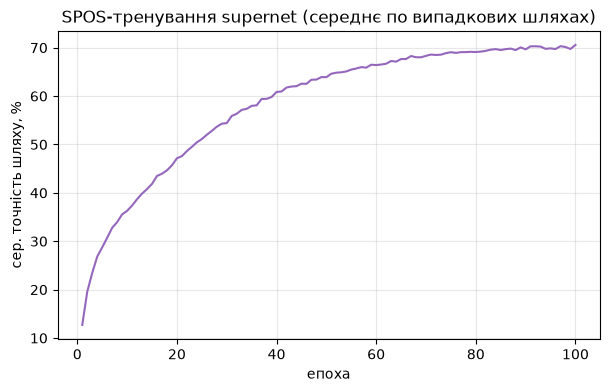

фінальна сер. точність шляху: 70.6%


In [3]:
h = search.get("supernet_history")
if h:
    fig, ax = plt.subplots(figsize=(7,4))
    ax.plot(range(1, len(h["train_acc"])+1), [a*100 for a in h["train_acc"]], color="tab:purple")
    ax.set_xlabel("епоха"); ax.set_ylabel("сер. точність шляху, %")
    ax.set_title("SPOS-тренування supernet (середнє по випадкових шляхах)")
    ax.grid(alpha=0.3); plt.show()
    print(f"фінальна сер. точність шляху: {h['train_acc'][-1]*100:.1f}%")
else:
    print("supernet перевикористано з наявних ваг — історію див. у логах run_search.py")

## 4. Пошук TPE (weight-sharing proxy)

TPE будує ймовірнісну модель «які конфігурації дають низький лос» і пропонує нові
кандидати, що максимізують очікуване покращення. Кожен trial коштує копійки: вибрати
під-шлях у натренованій supernet → рекалібрувати BN → порахувати **validation loss**.
Це proxy-оцінка; ми також фіксуємо кількість параметрів і proxy val-accuracy.

За 250 trial-ів TPE оцінив **139** унікальних архітектур (з
1620); решта 111 — повторні візити вже баченого (TPE
експлуатує вдалі зони — беремо їх з кешу). Кешовані trial-и не додають інформації,
тому на графіку збіжності вісь X — **кількість унікальних** архітектур, а не сирий
номер trial.

**Контроль — random search.** Щоб приписати виграш саме TPE, а не раннім вдалим
семплам, ми прогнали той самий бюджет **випадковим** пошуком по тій самій supernet і
наклали криві. Це прозора перевірка: якщо TPE не обганяє random, так і кажемо.

**Два обов'язкові графіки** (convergence — з random-контролем):

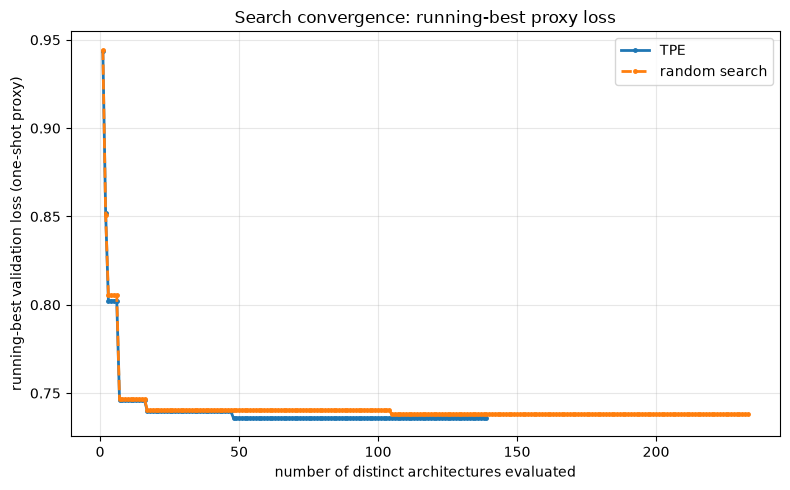

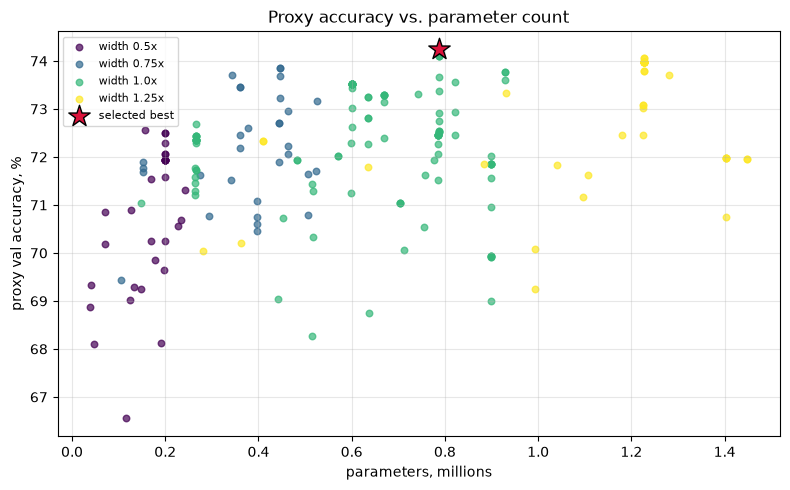

In [4]:
plots.plot_search_convergence(records, search.get("random_records")); plt.show()
plots.plot_acc_vs_params(records, search["best_arch"]); plt.show()

**Внесок TPE.** Найкращий proxy-loss TPE досяг уже на **48-й** унікальній
архітектурі. На цьому невеликому просторі (хороший регіон широкий — багато робочих
`conv3x3`-на-вході дизайнів) TPE і random виходять на близький найкращий proxy
(TPE best-acc 74.24% vs random 74.04%): перевага
sequential-моделі над random тут помірна, бо знайти хорошу зону легко. Це — валідний
результат, а не хиба (див. графік). **Застереження:** random-контроль тут — **один**
прогін; для строгого твердження «TPE > random» треба 3–5 random-seed-ів і band/mean
(див. розділ «як покращити»).

**Що знайшов пошук.** Топ-архітектури за proxy узгоджені — пошук збігся на чіткий
структурний мотив:

- **стадія 0 → `conv3x3`** (conv3x3×15): перший шар з «сирих» 3 каналів
  хоче повну згортку;
- **стадія 1 → `mbconv`** (mbconv×13, conv3x3×2): inverted residual у середині;
- стадія 2 → mbconv×13, conv3x3×2; стадія 3 → conv3x3×13, mbconv×2;
- ширина: 1.0×8, 1.25×4, 0.75×3; активація: relu×6, gelu×4, relu6×3, leakyrelu×2.

Найгірші архітектури — усі-`dwsep` при ширині 0.5× — падають до ~67% proxy-точності;
proxy впевнено відсіює їх. **Найкраща за proxy:** `conv3x3/mbconv/mbconv/conv3x3, 1.0×, relu`, 0.79M,
proxy val-acc = 74.24%.

## 5. Retrain з нуля vs baseline

Proxy лише **ранжує**; фінальне число дає навчання обраної архітектури **з нуля** як
звичайної мережі (120 епох, cosine LR). Порівнюємо з двома
baseline: (1) заморожена VGG11 з ДЗ1 (той самий baseline через усі ДЗ) і (2) **in-space
default** (усі `conv3x3`, 1.0×, ReLU) з ідентичним рецептом — щоб приписати виграш саме
пошуку, а не іншій «родині» архітектур.

Оскільки розрив best↔default малий, кожну мережу тренуємо на **3 seed-ах**
(42, 43, 44) і наводимо **mean ± std**. Порядок батчів прив'язаний до
seed окремим генератором (незалежно від RNG-ініціалізації), тож на кожному seed обидві
мережі бачать **однаковий** порядок даних — контрольоване порівняння.

Методологія: відбір моделі — на **validation**; **test** вимірюємо рівно раз на кожну
фінальну (модель, seed).

| Модель | Параметри | vs baseline | Val acc | **Test acc** |
|---|---|---|---|---|
| Baseline VGG11 (ДЗ1) | 9.49M | 1.0× | — | 90.71% |
| In-space default | 0.96M | 9.8× менше | 90.88 ± 0.26% | 90.16 ± 0.17% |
| **Знайдена пошуком** | **0.79M** | **12.1× менше** | 91.97 ± 0.29% | **91.02 ± 0.16%** |

Знайдена мережа = 91.02 ± 0.16% проти 90.71% у
baseline при **12.1× менше параметрів**, і +0.86 п.п. над default. Різниця
best↔default (+0.86 п.п.) перевищує сумарний
розкид (±0.16/±0.17 п.п.) — тож інтерпретуємо її
як реальну.
Крива навчання найкращої архітектури (seed 42):

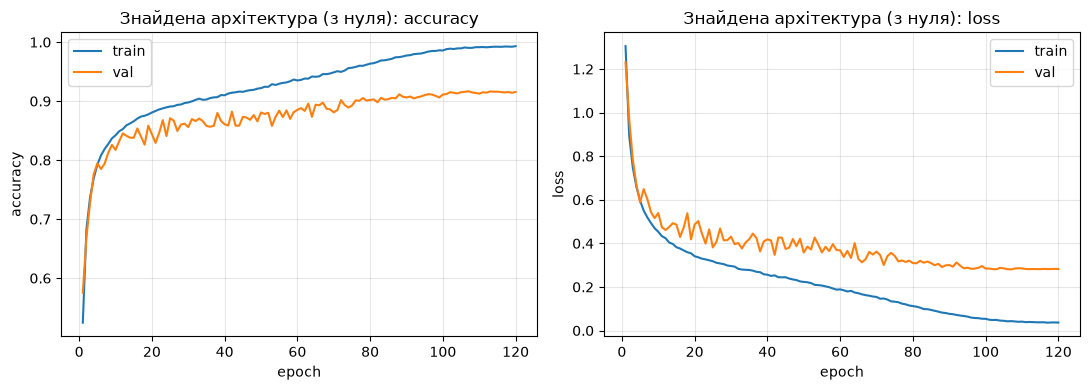

In [5]:
plots.plot_history(retrain["best"]["history"], title="Знайдена архітектура (з нуля)")
plt.show()

## 6. Бонус — наскільки інформативний one-shot proxy?

На питання зі звіту «how informative was the one-shot proxy?» відповідаємо **числами** з
p-values, а не відчуттям. Але не лише на топі: **top-only** нічого не каже про грубий
відсів. Тому беремо **стратифіковану** вибірку з 21 архітектур, що покриває **весь**
діапазон proxy (по квантилях: низ / середина / верх), тренуємо кожну коротко з нуля
(15 епох × 2 seed-и, усереднення)
і рахуємо кореляцію на всій вибірці **і** окремо на топ-6.

- **Грубий відсів (уся вибірка, n=21):** Kendall τ = **0.57**
  (p<0.001), Spearman ρ = **0.79**
  (p<0.001). Значущо —
  proxy надійно відрізняє погані архітектури від хороших.
- **Тонке ранжування (топ-6):** Kendall τ = **-0.07**
  (p=1.000), Spearman ρ = **0.03**. Серед топу
  proxy-точності лежать у вузькому діапазоні 0.4 п.п. (усі
  ~74.24%), тоді як справжні короткі — у 1.2 п.п.:
  найкращі архітектури **майже нерозрізнимі** під спільними вагами, і вибір переможця —
  це вже шум.

Графік — уся стратифікована вибірка (сильний загальний тренд = добрий грубий відсів):

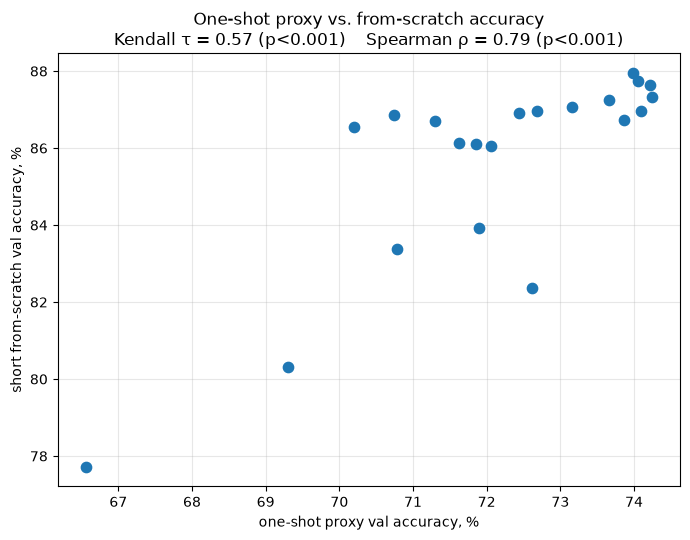

proxy=0.6656  short=0.7772  0.12M  dwsep/dwsep/dwsep/mbconv w0.5 leakyrelu
proxy=0.6930  short=0.8032  0.13M  conv3x3/conv3x3/dwsep/mbconv w0.5 relu
proxy=0.7020  short=0.8654  0.36M  mbconv/dwsep/mbconv/dwsep w1.25 silu
proxy=0.7074  short=0.8685  1.40M  conv3x3/dwsep/conv3x3/conv3x3 w1.25 silu
proxy=0.7078  short=0.8337  0.29M  conv3x3/conv3x3/dwsep/mbconv w0.75 gelu
proxy=0.7130  short=0.8670  0.26M  mbconv/mbconv/mbconv/dwsep w1.0 gelu
proxy=0.7162  short=0.8612  0.76M  conv3x3/dwsep/mbconv/conv3x3 w1.0 leakyrelu
proxy=0.7186  short=0.8610  0.90M  conv3x3/dwsep/conv3x3/conv3x3 w1.0 relu
proxy=0.7190  short=0.8392  0.44M  dwsep/mbconv/mbconv/conv3x3 w0.75 relu
proxy=0.7206  short=0.8606  0.46M  mbconv/conv3x3/mbconv/conv3x3 w0.75 silu
proxy=0.7244  short=0.8690  0.27M  conv3x3/mbconv/mbconv/dwsep w1.0 leakyrelu
proxy=0.7262  short=0.8236  0.60M  mbconv/mbconv/mbconv/mbconv w1.0 silu
proxy=0.7268  short=0.8697  0.27M  conv3x3/mbconv/mbconv/dwsep w1.0 gelu
proxy=0.7316  short=0.8707  

In [6]:
proxy = [r["proxy_val_acc"] for r in corr["rows"]]
real  = [r["short_val_acc"] for r in corr["rows"]]
plots.plot_proxy_correlation(proxy, real,
    tau=corr["full"]["kendall_tau"], rho=corr["full"]["spearman_rho"],
    tau_p=corr["full"]["kendall_p"], rho_p=corr["full"]["spearman_p"])
plt.show()
for r in sorted(corr["rows"], key=lambda x: x["proxy_val_acc"]):
    print(f'proxy={r["proxy_val_acc"]:.4f}  short={r["short_val_acc"]:.4f}  '
          f'{r["params"]/1e6:.2f}M  {"/".join(r["arch"]["ops"])} w{r["arch"]["width"]} {r["arch"]["act"]}')

## 7. Висновки (звіт)

**Що спрацювало добре.**
- Пошук знайшов архітектуру **12.1× меншу** за VGG11 із практично тією ж
  точністю (91.02 ± 0.16% vs 90.71%) — головна
  ціль NAS (краще співвідношення точність/розмір) досягнута.
- **Weight sharing зробив пошук дешевим:** одна supernet (100 епох)
  + 250 майже безкоштовних trial-ів замість 1620 повних
  тренувань. Оцінка одного кандидата — рекалібрація BN + один прохід по val.
- **Proxy впевнено знаходить хороший регіон:** на стратифікованій вибірці кореляція
  proxy↔реальне навчання значуща (τ=0.57, p<0.001),
  топ збігся на чіткий мотив, найгірші (усі-`dwsep`, 0.5×) відсіяні. Грубий відсів — надійний.

**Що не спрацювало / вийшло не як очікувалось.**
- **Тонке ранжування proxy — слабке** (топ-6: τ=-0.07,
  p=1.000 — статистично незначущо). Серед топу spread proxy — лише
  0.4 п.п., тож обрати «найкращу з найкращих» proxy не може; фінальний
  вибір усередині топу — майже випадковий. Це відома вада one-shot: co-adaptation
  спільних ваг вирівнює сильних кандидатів.
- **Розрив proxy↔реальне навчання великий за абсолютом** (proxy ~73% vs справжні
  84–91%): спільні ваги недо-треновані для кожного окремого шляху. Для *ранжування*
  це прийнятно, для *абсолютної* оцінки — ні.
- **TPE лише трохи кращий за random** на цьому просторі (best-acc 74.24% vs
  74.04%; вийшов на best за 48 унікальних): хороша зона
  широка. Але random-контроль — **один** прогін, тож це слабке твердження; надійніше —
  3–5 random-seed-ів. Виграв би виразніше на більшому/складнішому просторі.

**Наскільки інформативний one-shot proxy?** Двошарова відповідь, тепер з p-values:
**для грубого відсіву — надійно** (τ=0.57, p<0.001
на всьому діапазоні), **для тонкого вибору переможця — ні** (топ-6:
τ=-0.07, p=1.000). На практиці proxy — це **фільтр**
(звузити 1620 → десяток кандидатів), а фінал вирішувати коротким
до-навчанням — рівно як ми зробили в бонусі.

**Як покращити результати.**
- **Random-контроль на 3–5 seed-ах** (band/mean) — щоб твердження «TPE > random» стало
  статистично надійним, а не одноразовим порівнянням.
- Тренувати supernet довше + **fairness-трюки** (FairNAS: кожен батч — усі операції по
  черзі) або sandwich-rule, щоб зменшити co-adaptation і підняти τ на топі.
- Оцінювати кандидатів на **більшій підвибірці val** і з більшою BN-рекалібрацією
  (менше шуму в proxy); більше seed-ів у proxy-study.
- Розширити простір (глибина / kernel size / окремий stride) — зараз макро-скелет
  фіксований, тож і виграш TPE над random, і виграш пошуку обмежені.
- Ще більше **seed-ів** для retrain (тут 3) для тіснішого CI на розриві best↔default.

## 8. Як ми це зробили / що пробували

- **Реюз, а не переписування.** Supernet — це пряме розширення `ElasticVGG11` з
  бонусу ДЗ3: той самий slimmable-зріз `W[:out, :in]` і та сама ідея BN-рекалібрації,
  лише додано вибір **операції** на стадію. `data`/`engine`/`model`/`utils` — без змін
  з ДЗ1–ДЗ3.
- **Чесний підрахунок параметрів.** Кількість параметрів рахуємо не аналітичною
  формулою, а **побудовою** реальної `StandaloneNet` — і тестом звіряємо, що зрізи ваг
  supernet мають **точно ті самі форми**, що й standalone-архітектура. Тобто «шукали
  одну мережу, а тренуємо іншу» тут неможливо за побудовою.
- **Fair baseline з контролем seed.** Порівнюємо не лише з VGG11, а й з in-space default
  при **ідентичному** рецепті; best і default тренуємо на **3 seed-ах** з
  однаковим (генератором-прив'язаним) порядком батчів на кожному seed → різниця не
  списується на удачу ініціалізації/порядку даних.
- **Дисципліна даних.** Увесь пошук і кожне проміжне число — на **validation**; test
  чіпаємо рівно раз на кожну фінальну (модель, seed). `inference_mode` в оцінці.
- **Контроль пошуку.** Додали random-search baseline на тій самій supernet — щоб
  бачити внесок саме TPE, а не раннього вдалого семплу; вісь збіжності — за
  **унікальними** архітектурами (кеш-візити інформації не додають).
- **На чому спіткнулись.** (1) BN у one-shot: без рекалібрації активного шляху
  proxy-точність — сміття (running stats змішані по всіх ширинах); рекалібрація на
  ~64 батчах це лікує. (2) Слабка τ на топі спочатку виглядала як
  баг, але це реальна властивість — топ-кандидати нерозрізнимі під спільними вагами;
  ми лишили це число як є й додали стратифіковану вибірку, щоб окремо показати надійний
  грубий відсів. (3) Оцінку proxy стратифікували по квантилях — top-only не доводить
  якість фільтра.

## 9. Джерела

- Bergstra, Bardenet, Bengio, Kégl. *Algorithms for Hyper-Parameter Optimization.*
  NeurIPS 2011. (TPE — алгоритм, який використовує Hyperopt.)
- Bergstra, Yamins, Cox. *Hyperopt: A Python Library for Optimizing Hyperparameters.*
  SciPy 2013. — <https://github.com/hyperopt/hyperopt>
- Guo et al. *Single Path One-Shot Neural Architecture Search with Uniform Sampling.*
  ECCV 2020 (arXiv:1904.00420). — схема тренування supernet.
- Howard et al. *MobileNets.* 2017 (depthwise-separable); Sandler et al.
  *MobileNetV2: Inverted Residuals and Linear Bottlenecks.* CVPR 2018 — операції блоків.
- Yu, Huang. *Universally Slimmable Networks* / *Slimmable Neural Networks.* ICLR 2019 —
  ідея спільних ваг за шириною + per-width BN (яку ми реюзаємо з бонусу ДЗ3).